## The Position Effect

**Research question:** Does attention to the gold passage drop when it is placed in the middle of the context (aka Lost-in-the-Middle)? Verifying this mechanistically on GPT-2's attention weights —  direct evidence for why `position` is an axis in the phase diagram.


In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

# Reuse GPT-2 if already loaded in this kernel session for speeed
if 'model' not in dir() or getattr(getattr(model, 'cfg', None), 'model_name', '') != 'gpt2':
    model = HookedTransformer.from_pretrained("gpt2")
    model.eval()
    print("Loaded gpt2")
else:
    print("Reusing gpt2 already in session")

GOLD_FACT = "The capital of France is Paris."
FILLER    = "The sky is blue. Water is wet. Dogs are mammals. Trees grow tall. Birds can fly. "
QUESTION  = " What is the capital of France? Answer in one word."

def make_context(position: str) -> str:
    pad = FILLER * 5
    if position == "start":  return GOLD_FACT + " " + pad + QUESTION
    if position == "end":    return pad + " " + GOLD_FACT + QUESTION
    half = FILLER * 2
    return half + " " + GOLD_FACT + " " + half + QUESTION

POSITIONS = ["start", "middle", "end"]
caches = {}
for pos in POSITIONS:
    prompt   = make_context(pos)
    tokens   = model.to_tokens(prompt)
    str_toks = model.to_str_tokens(prompt)
    with torch.no_grad():
        logits, cache = model.run_with_cache(tokens)
        gen_ids = model.generate(tokens, max_new_tokens=10, temperature=0, stop_at_eos=False)
    response = model.tokenizer.decode(gen_ids[0, tokens.shape[1]:], skip_special_tokens=True)
    caches[pos] = {"cache": cache, "str_toks": str_toks, "response": response}
    print(f"{pos:6s} | tokens: {len(str_toks):3d} | response: {response!r}")


Reusing gpt2 already in session


  0%|          | 0/10 [00:00<?, ?it/s]

start  | tokens: 126 | response: ' Paris is the capital of France. The sky is'


  0%|          | 0/10 [00:00<?, ?it/s]

middle | tokens: 106 | response: '  The capital of France is Paris. The sky'


  0%|          | 0/10 [00:00<?, ?it/s]

end    | tokens: 126 | response: ' The capital of France is Paris. What is the'


In [41]:
caches["start"]["str_toks"]

['<|endoftext|>',
 'The',
 ' capital',
 ' of',
 ' France',
 ' is',
 ' Paris',
 '.',
 ' The',
 ' sky',
 ' is',
 ' blue',
 '.',
 ' Water',
 ' is',
 ' wet',
 '.',
 ' Dogs',
 ' are',
 ' mammals',
 '.',
 ' Trees',
 ' grow',
 ' tall',
 '.',
 ' Birds',
 ' can',
 ' fly',
 '.',
 ' The',
 ' sky',
 ' is',
 ' blue',
 '.',
 ' Water',
 ' is',
 ' wet',
 '.',
 ' Dogs',
 ' are',
 ' mammals',
 '.',
 ' Trees',
 ' grow',
 ' tall',
 '.',
 ' Birds',
 ' can',
 ' fly',
 '.',
 ' The',
 ' sky',
 ' is',
 ' blue',
 '.',
 ' Water',
 ' is',
 ' wet',
 '.',
 ' Dogs',
 ' are',
 ' mammals',
 '.',
 ' Trees',
 ' grow',
 ' tall',
 '.',
 ' Birds',
 ' can',
 ' fly',
 '.',
 ' The',
 ' sky',
 ' is',
 ' blue',
 '.',
 ' Water',
 ' is',
 ' wet',
 '.',
 ' Dogs',
 ' are',
 ' mammals',
 '.',
 ' Trees',
 ' grow',
 ' tall',
 '.',
 ' Birds',
 ' can',
 ' fly',
 '.',
 ' The',
 ' sky',
 ' is',
 ' blue',
 '.',
 ' Water',
 ' is',
 ' wet',
 '.',
 ' Dogs',
 ' are',
 ' mammals',
 '.',
 ' Trees',
 ' grow',
 ' tall',
 '.',
 ' Birds',
 ' can',
 

In [44]:
# which token indices in str_tokens correspond to the gold passage.
# The gold passage contains the words in `keywords`.
# Return a list of integer indices into str_toks.
#
# note that GPT-2 tokenises 'Paris' as a single token but 'capital' may split.

def find_gold_indices(str_toks: list[str], keywords: list[str]) -> list[int]:
    """Return indices of tokens that are part of the gold passage."""
    indices = []
    for i, tok in enumerate(str_toks):
        for kw in keywords:
            if kw.lower() in tok.lower():  # case-insensitive substring match
                indices.append(i)
                break  # stop checking other keywords for this token
    return indices


# Test: 'Paris' and 'France' should appear in start position
gold_kw  = ["Paris"]
idxs     = find_gold_indices(caches["start"]["str_toks"], gold_kw)
print(f"Gold token indices (start): {idxs}")
print(f"Tokens at those indices: {[caches['start']['str_toks'][i] for i in idxs]}")

Gold token indices (start): [6]
Tokens at those indices: [' Paris']


In [45]:
# For each layer, computing how much attention the FINAL query position
# (where the next-token prediction happens) pays to the gold tokens.
#
# cache["pattern", layer] has shape [1, n_heads, q_pos, k_pos]
#
# Return: dict {layer_int: float}

def gold_attention_per_layer(pos: str, keywords: list[str]) -> dict[int, float]:
    cache    = caches[pos]["cache"]
    str_toks = caches[pos]["str_toks"]
    gold_idxs = find_gold_indices(str_toks, keywords)
    if not gold_idxs:
        print(f"Warning: no gold tokens found for position={pos}")
        return {}
    attention_scores = {}
    for layer in range(model.cfg.n_layers):
        pattern = cache["pattern", layer]
        avg_attention = pattern.mean(dim=1)
        total_attention = sum(avg_attention[0, -1, gold_idx] for gold_idx in gold_idxs)
        attention_scores[layer] = total_attention.item()
    return attention_scores

gold_kw = ["Paris"]
layer_scores = {pos: gold_attention_per_layer(pos, gold_kw) for pos in POSITIONS}
for pos in POSITIONS:
    print(f"\nAttention to gold tokens for position={pos}:")
    for layer, score in layer_scores[pos].items():
        print(f"  Layer {layer:2d}: {score:.4f}")
    print(f"Average across all layers: {np.mean(list(layer_scores[pos].values())):.4f}")



Attention to gold tokens for position=start:
  Layer  0: 0.0014
  Layer  1: 0.0056
  Layer  2: 0.0036
  Layer  3: 0.0002
  Layer  4: 0.0003
  Layer  5: 0.0003
  Layer  6: 0.0006
  Layer  7: 0.0063
  Layer  8: 0.0060
  Layer  9: 0.0550
  Layer 10: 0.0739
  Layer 11: 0.0423
Average across all layers: 0.0163

Attention to gold tokens for position=middle:
  Layer  0: 0.0018
  Layer  1: 0.0037
  Layer  2: 0.0028
  Layer  3: 0.0002
  Layer  4: 0.0002
  Layer  5: 0.0002
  Layer  6: 0.0005
  Layer  7: 0.0033
  Layer  8: 0.0032
  Layer  9: 0.0612
  Layer 10: 0.0744
  Layer 11: 0.0434
Average across all layers: 0.0162

Attention to gold tokens for position=end:
  Layer  0: 0.0063
  Layer  1: 0.0128
  Layer  2: 0.0077
  Layer  3: 0.0020
  Layer  4: 0.0022
  Layer  5: 0.0010
  Layer  6: 0.0046
  Layer  7: 0.0061
  Layer  8: 0.0136
  Layer  9: 0.0716
  Layer 10: 0.0886
  Layer 11: 0.0509
Average across all layers: 0.0223


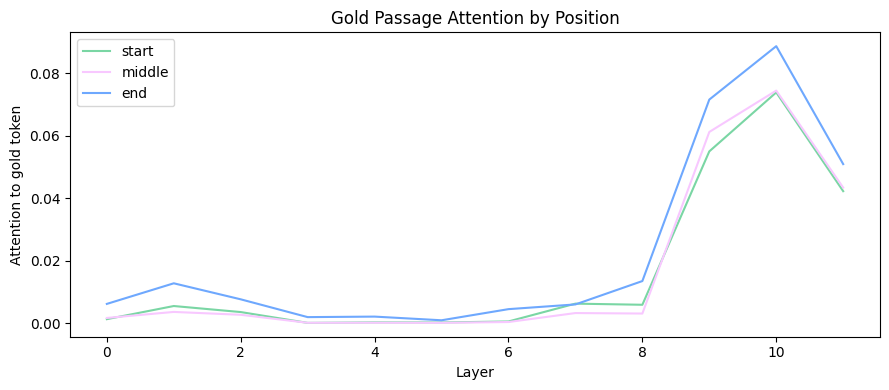


Mean attention to gold tokens (avg over layers):
  start : 0.0163  | response: ' Paris is the capital of France. The sky is'
  middle: 0.0162  | response: '  The capital of France is Paris. The sky'
  end   : 0.0223  | response: ' The capital of France is Paris. What is the'


In [46]:
colors = {"start": "#7ad6a4", "middle": "#f8c8ff", "end": "#6ea8fe"}
fig, ax = plt.subplots(figsize=(9, 4))

for pos in POSITIONS:
    scores = layer_scores.get(pos, {})
    if scores:
        ax.plot(list(scores.keys()), list(scores.values()), label=pos, color=colors[pos])

ax.set_xlabel("Layer")
ax.set_ylabel("Attention to gold token")
ax.set_title("Gold Passage Attention by Position")
ax.legend()
plt.tight_layout()
plt.savefig("attention_position.png")
plt.show()

print("\nMean attention to gold tokens (avg over layers):")
for pos in POSITIONS:
    scores = layer_scores.get(pos, {})
    if scores:
        print(f"  {pos:6s}: {np.mean(list(scores.values())):.4f}  | response: {caches[pos]['response']!r}")


1. Which position (start / middle / end) receives the least attention to the gold passage?
2. At which layers is the difference most pronounced? Early, middle, or late?
3. Does the model still predict the correct answer even when gold-passage attention is low? What does that tell you about how robust the model is?
4. **Research implication:** How does this explain the shape of the phase diagram's position axis?

The end recieved the least attention wwhich makes sense as tehres fewwer tokens that can attend to it 
end layer - 10 - is most pronounced, likely since thats where the model is closer to reconsiling differences and making a prediction, to it cares about the semantics more. 
In all cases the anwer included was still correct, indicating that inductive power of the model is not bad. 
Overall, however, as the model is both trained on factual info being at the start/end and due to the fact that theres BOS attention heads + stronger attention to end of sentence, mid sentence in general is less attended to. However, unlike research, here we see attention dropping for end position too. 

NOTE: if your question contains the tokens you are testing attention to it will pollute the plot. absolute answer should not be in the question. 